In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = sns.load_dataset('titanic')
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
print(" Missing Values : ")
print(df.isnull().sum())
print("\n Data Types :")
print(df.dtypes)


 Missing Values : 
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

 Data Types :
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


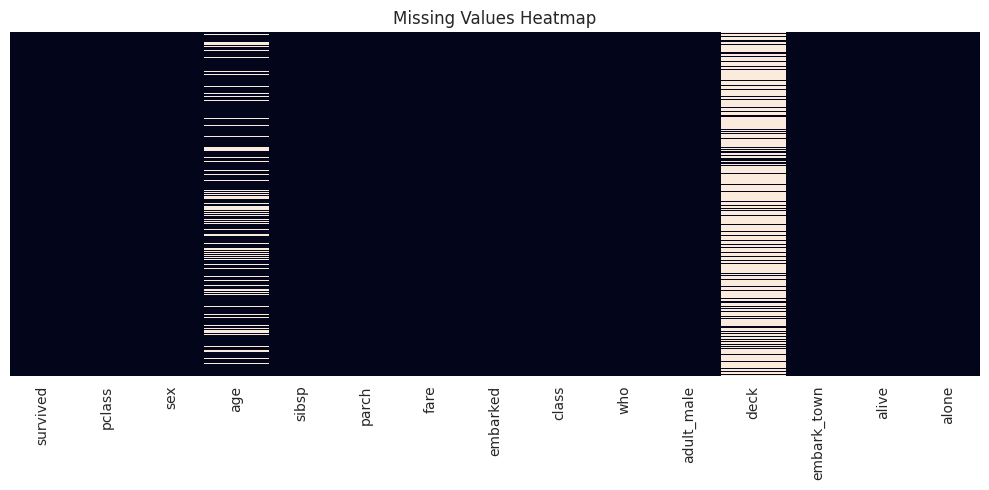

In [14]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

In [15]:
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df.drop(columns=['deck', 'embark_town', 'alive', 'who', 'adult_male'], inplace=True)

print("After cleaning:")
print(df.isnull().sum())

After cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
alone       0
dtype: int64


/tmp/ipykernel_2059/3989081659.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_2059/3989081659.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

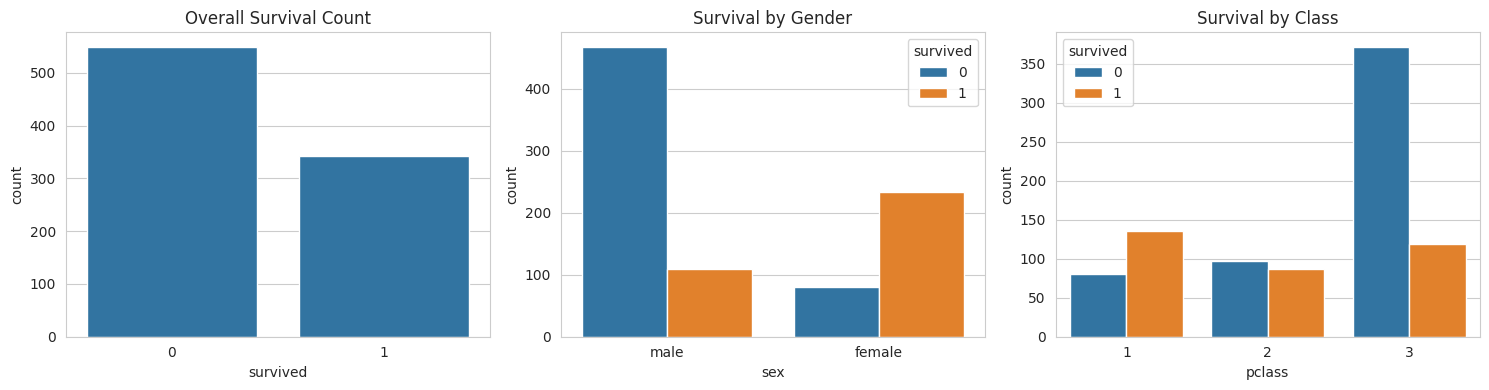

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='survived', ax=axes[0])
axes[0].set_title('Overall Survival Count')

sns.countplot(data=df, x='sex', hue='survived', ax=axes[1])
axes[1].set_title('Survival by Gender')

sns.countplot(data=df, x='pclass', hue='survived', ax=axes[2])
axes[2].set_title('Survival by Class')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2059/3243151003.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='survived', y='age', palette='Set2')


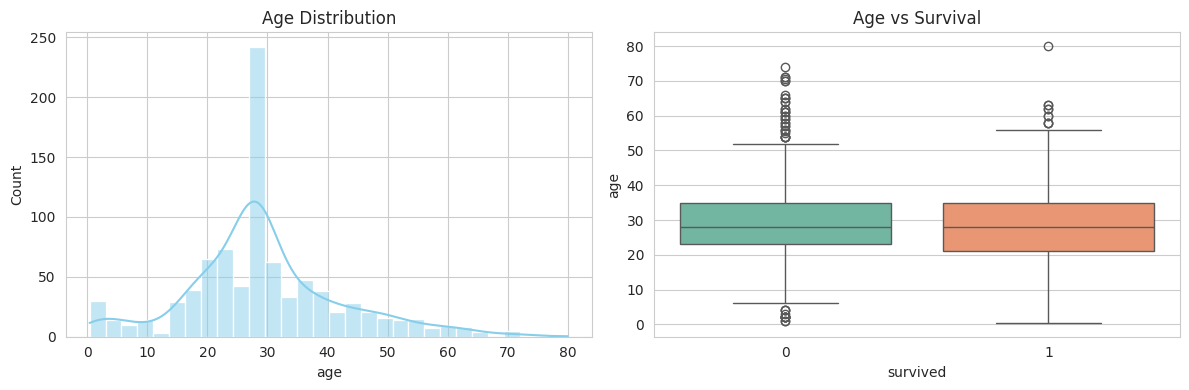

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, color='skyblue', bins=30)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='survived', y='age', palette='Set2')
plt.title('Age vs Survival')

plt.tight_layout()
plt.show()

In [18]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df.drop(columns=['class'], inplace=True)

print("Final shape:", df.shape)
df.to_csv('titanic_clean.csv', index=False)
print("Saved!")

Final shape: (891, 9)
Saved!
